In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

start_date = "2021-12-31"
end_date   = "2025-12-31"

**DCC-GARCH Constrained Mean-Variance Optimisation Portfolio**
---
---

In [2]:
url='https://raw.githubusercontent.com/BoraY888/AI-Value-Chain-Portfolio-Optimisation/e56449b489957421500cfd7b6eb46c63bdb2ccec/port_data_usd.csv'

port_data_usd = pd.read_csv(url, index_col=0, parse_dates=True)

combined_ret = port_data_usd.pct_change()

/tmp/ipykernel_471/300018956.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  combined_ret = port_data_usd.pct_change()


In [3]:
ticker_list = combined_ret.columns.tolist()

metadata_list = []

for ticker in ticker_list:
    try:
        info = yf.Ticker(ticker).info
        metadata_list.append({
            "ticker": ticker,
            "sector": info.get("sector"),
            "industry": info.get("industry")
        })
    except Exception:
        metadata_list.append({"ticker": ticker, "sector": "N/A", "industry": "N/A"})

stock_metadata = pd.DataFrame(metadata_list)

stock_metadata = stock_metadata.set_index("ticker")

print(stock_metadata['industry'])

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: FVJA.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HWHG.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IZ1.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PKX.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 66T.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AOR.BE"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: S

ticker
ADI                                     Semiconductors
ALAB                                    Semiconductors
AMAT               Semiconductor Equipment & Materials
AMD                                     Semiconductors
ASML               Semiconductor Equipment & Materials
AVGO                                    Semiconductors
CRDO                                    Semiconductors
ENTG               Semiconductor Equipment & Materials
INTC                                    Semiconductors
KLAC               Semiconductor Equipment & Materials
LRCX               Semiconductor Equipment & Materials
MCHP                                    Semiconductors
MPWR                                    Semiconductors
MRVL                                    Semiconductors
MTSI                                    Semiconductors
MU                                      Semiconductors
NVDA                                    Semiconductors
NVMI               Semiconductor Equipment & Materials
NXP

In [4]:
industry_map = {
    # 1. Semiconductors
    'Semiconductors': 'Semiconductors',
    'Semiconductor Equipment & Materials': 'Semiconductors',
    'Electronic Components': 'Semiconductors', # Often logic/memory chips

    # 2. Metals and Mining
    'Other Industrial Metals & Mining': 'Metals and Mining',
    'Aluminum': 'Metals and Mining',
    'Copper': 'Metals and Mining',
    'Steel': 'Metals and Mining',
    'Other Precious Metals & Mining': 'Metals and Mining',

    # 3. Utilities (The Power Grid)
    'Utilities - Regulated Electric': 'Utilities',
    'Utilities - Regulated Gas': 'Utilities',
    'Utilities - Regulated Water': 'Utilities',
    'Utilities - Independent Power Producers': 'Utilities',
    'Utilities - Diversified': 'Utilities',
    'Oil & Gas Midstream': 'Utilities',
    'Oil & Gas Integrated': 'Utilities',

    # 4. Renewable Energy (The "Green" AI requirement)
    'Solar': 'Renewable Energy',
    'Utilities - Renewable': 'Renewable Energy',

    # 5. Data Center Infrastructure (The Physical Shell & Connectivity)
    'REIT - Specialty': 'Data Center Infrastructure',
    'Information Technology Services': 'Data Center Infrastructure',
    'Telecom Services': 'Data Center Infrastructure',
    'Computer Hardware': 'Data Center Infrastructure',
    'Electrical Equipment & Parts': 'Data Center Infrastructure',
    'Engineering & Construction': 'Data Center Infrastructure',
    'Building Products & Equipment': 'Data Center Infrastructure',
    'Specialty Industrial Machinery': 'Data Center Infrastructure',
    'Building Materials': 'Data Center Infrastructure',
    'Real Estate Services': 'Data Center Infrastructure',
    'REIT - Office': 'Data Center Infrastructure',
    'Rental & Leasing Services': 'Data Center Infrastructure',
    'Scientific & Technical Instruments': 'Data Center Infrastructure'
}

# 2. Apply it to your metadata dataframe
stock_metadata['valchain_industry'] = stock_metadata['industry'].map(industry_map)

# 3. Fill anything that didn't match as "Other"
stock_metadata['valchain_industry'] = stock_metadata['valchain_industry'].fillna('Other')

In [5]:
!pip install arch
from arch import arch_model

egarch_results = {}
min_obs = 500

for col in combined_ret.columns:
    series = combined_ret[col].dropna()

    if len(series) < min_obs:
      print(f"{col}: Insufficient Data - {len(series)} Days of Returns")
      continue

    model = arch_model(
        series,           #arch_model requires 1D input
        p=1,              #p is the number of lagged/delayed log-volatility terms. Represents how long it takes shock-induced volatility to decay (1=yesterday's forecast)
        o=1,              #o is the asymmetric term. Captures the leverage effect (bad news increases volatility more than good news)
        q=1,              #q is the number of lagged residuals/errors. Represents how impactful the news is on volatility (1=yesterday's news)
        mean='constant',  #Mean does not change over time (Assumption)
        vol='EGARCH',     #EGARCH (Exponential GARCH) models the log of variance, allowing for asymmetric shocks with "o" variable
        dist='normal',    #Assume returns are normally distributed
        rescale=True      #Tiny daily returns such as 0.15% squared cause variance calculations to fail as computer loses precision
    )                     #GARCH(p=2, q=2) or over often overfits

    res = model.fit(disp="off", show_warning=False)
    if res.convergence_flag == 0:
      egarch_results[col] = res
      forecast = res.forecast(horizon=21, method='simulation')  #EGARCH is non-linear, so no analytical solution, therefore Monte-Carlo simulation used
      print(f"{col} modelled successfully")
    else:
      print(f"{col} did not converge")

print(f"\nFinal count of modeled stocks: {len(egarch_results)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.2 MB/s eta 0:00:00
ADI modelled successfully
ALAB modelled successfully
AMAT modelled successfully
AMD modelled successfully
ASML modelled successfully
AVGO modelled successfully
CRDO modelled successfully
ENTG modelled successfully
INTC modelled successfully
KLAC modelled successfully
LRCX modelled successfully
MCHP modelled successfully
MPWR modelled successfully
MRVL modelled successfully
MTSI modelled successfully
MU modelled successfully
NVDA modelled successfully
NVMI modelled successfully
NXPI modelled successfully
ON modelled successfully
QCOM modelled successfully
RMBS modelled successfully
TER modelled successfully
TSM modelled successfully
TXN modelled successfully
1211.SR modelled successfully
AA modelled successfully
AAL modelled successfully
ANTO.L modelled successfully
BHP modelled successfully
BWJ0.F modelled successfully
FCX modelled successfully
FVJA.BE: Insufficient Data - 0 Days of Returns
GLNCY modelled 

In [6]:
#Removing stocks with insufficient data and Non-Converging stocks as EGARCH couldn't find a stable solution for volatility
combined_ret_filtered = combined_ret.drop(columns=['S93.BE', '66T.BE', 'AOR.BE', 'PKX.BE', 'IZ1.BE', 'HWHG.BE', 'FVJA.BE',
                                                   'ABJA.MU', 'SBAC', '000660.KS', 'FGSGF', 'ROK', 'NUE'])

In [7]:
trad_month_vols = {}

for col, res in egarch_results.items():
    forecast = res.forecast(horizon=21, method='simulation')
    trading_month_vol = np.sqrt(forecast.variance.iloc[-1].sum())
    trad_month_vols[col] = trading_month_vol

In [8]:
annual_sharpe = (combined_ret.mean() / combined_ret.std()) * np.sqrt(252)

valchain_df = stock_metadata.copy()
valchain_df['Sharpe'] = annual_sharpe
valchain_df['EGARCH_vol'] = pd.Series(trad_month_vols)

valchain_df = valchain_df[valchain_df['valchain_industry'] != 'Other']

final_selection = []

for industry in valchain_df['valchain_industry'].unique():
  subset = valchain_df[valchain_df['valchain_industry'] == industry].copy()

  vol_cutoff = subset['EGARCH_vol'].quantile(0.8)      #Removing top 20% of stocks with highest volatility
  stable_stocks = subset[subset['EGARCH_vol'] <= vol_cutoff]

  top_5 = stable_stocks.nlargest(5, 'Sharpe')         #Top 5 per AI Value Chain Industry for Sharpe Ratio
  final_selection.append(top_5)

port_data_25 = pd.concat(final_selection)

In [9]:
port_data_25_tickers = port_data_25.index.tolist()

port_data_25_prices = port_data_usd[port_data_25_tickers]

port_data_25_prices = port_data_25_prices.ffill().dropna()

In [10]:
!pip install mgarch     #DCC-GARCH not available in arch library
import mgarch

dcc_returns = port_data_25_prices.pct_change().dropna()

dist_model = mgarch.mgarch()     #Initialise multivariate GARCH with same distribution assumption as EGARCH

dist_model.fit(dcc_returns)         #Calculates conditional variance for each stock and dynamic correlations between them

prediction = dist_model.predict(1)     #Removes static covariance matrix, finds risk state at January 1st 2026

dcc_cov_matrix = prediction['cov']

#RESCALING
dcc_vols = np.sqrt(np.diag(dcc_cov_matrix))
dcc_corr = dcc_cov_matrix / np.outer(dcc_vols, dcc_vols)    #Extracting correlation matrix (Corr = Cov / Std_i * Std_j)

real_daily_vols = dcc_returns.std().values

corrected_daily_cov = np.outer(real_daily_vols, real_daily_vols) * dcc_corr     #Scale-Correccted Daily Covariance, Sigma = Vol_Matrix * Correlation_Matrix * Vol_Matrix

sigma_annualised = corrected_daily_cov * 252

dcc_sigma = pd.DataFrame(sigma_annualised, index=port_data_25_tickers, columns=port_data_25_tickers)    #Conversion to DataFrame for PyPortfolioOpt

In [11]:
#Cardinality Constraint
!pip install PyPortfolioOpt
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import objective_functions

mu = expected_returns.mean_historical_return(port_data_25_prices)

sigma = dcc_sigma

sector_map = port_data_25['valchain_industry'].to_dict()

ef_constrained = EfficientFrontier(mu, sigma, weight_bounds=(0.01, 1))    #14 stocks at 0 after L2 regularisation, min weight per stock 1%

ef_constrained.add_sector_constraints(sector_map, sector_lower={},
                                      sector_upper={'Semiconductors': 0.30,
                                                    'Metals and Mining': 0.30,
                                                    'Utilities': 0.30,
                                                    'Renewable Energy': 0.30,
                                                    'Data Center Infrastructure': 0.30})

ef_constrained.add_objective(objective_functions.L2_reg, gamma=0.1) #17 of 25 stocks were allocated 0 funds, L2 regularisation is added to penalise zero-weights and improve diversification

weights_final = ef_constrained.max_sharpe()
cleaned_final = ef_constrained.clean_weights()

print("--- Constrained Portfolio Weights ---")
print(cleaned_final)
print("\n--- Constrained Performance ---")
ef_constrained.portfolio_performance(verbose=True)

#2.39 Sharpe Ratio is great
#20.3% volatility matches S&P500 estimate of 19-22% in 2025

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.3 MB/s eta 0:00:00
--- Constrained Portfolio Weights ---
OrderedDict({'CRDO': 0.15731, 'AVGO': 0.02311, 'APH': 0.07504, 'NVDA': 0.01, 'ALAB': 0.01, 'STLD': 0.01, 'GXD.F': 0.14047, 'GMEXICOB.MX': 0.02818, 'RS': 0.01, 'TECK': 0.01, 'ET': 0.01, 'ATO': 0.09501, 'ETR': 0.07395, 'NI': 0.03785, 'CNP': 0.0832, 'EME': 0.01, 'POWL': 0.01, 'VRT': 0.01, 'PH': 0.05613, 'SMCI': 0.01, 'NXT': 0.01, 'ENLT': 0.06329, 'GCPEF': 0.01, 'RUN': 0.01, 'ENRG.TA': 0.03647})

--- Constrained Performance ---
Expected annual return: 48.5%
Annual volatility: 20.3%
Sharpe Ratio: 2.39


/usr/local/lib/python3.12/dist-packages/pypfopt/efficient_frontier/efficient_frontier.py:259: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


(np.float64(0.48492893018544836),
 np.float64(0.20256708666801468),
 np.float64(2.3939176801224074))

In [12]:
mvo_weights_series = pd.Series(cleaned_final)     #conversion to series for QuantStats implementation

mvo_daily_rets = port_data_25_prices.pct_change().mul(mvo_weights_series, axis=1).sum(axis=1)

mvo_daily_rets = mvo_daily_rets.fillna(0)

**DCC-GARCH Dynamic Market Cap Adjusted Portfolio**
---
---

In [13]:
target_sector_weight = 0.20

shares = {}
for ticker in port_data_25_tickers:
    shares[ticker] = yf.Ticker(ticker).info.get('sharesOutstanding', 1)       #Shares Outstanding - metadata used to calculate Market Cap

def calculate_dynamic_weights(current_prices):
    weights = {}

    for industry in port_data_25['valchain_industry'].unique():
        industry_stocks = port_data_25[port_data_25['valchain_industry'] == industry].index

        mkt_caps = {t: current_prices[t] * shares[t] for t in industry_stocks}
        total_industry_cap = sum(mkt_caps.values())

        for t in industry_stocks:
            weights[t] = (mkt_caps[t] / total_industry_cap) * target_sector_weight #Stock Market Cap / Total Market Cap from same industry * 20% max allocation for industry

    return weights

start_weights = calculate_dynamic_weights(port_data_25_prices.iloc[0])      #1-1-2022 Price
end_weights = calculate_dynamic_weights(port_data_25_prices.iloc[-1])       #30-12-2025 Price

In [14]:
weight_shift = pd.DataFrame({
    'Start_Weight %': pd.Series(start_weights) * 100,
    'End_Weight %': pd.Series(end_weights) * 100
})

weight_shift['Change'] = weight_shift['End_Weight %'] - weight_shift['Start_Weight %']

print(weight_shift.sort_values(by='Change', ascending=False).head(5))   #Top 5 Changes

             Start_Weight %  End_Weight %    Change
VRT                3.452974      5.413762  1.960788
PH                 7.996904      9.659235  1.662331
GMEXICOB.MX        7.902104      9.517782  1.615679
ETR                3.685555      4.943959  1.258404
AVGO               4.190390      5.146647  0.956257


In [15]:
def calculate_staggered_returns(df_prices, weights_dict):
    daily_rets = df_prices.pct_change()

    w_series = pd.Series(weights_dict)

    weighted_rets = daily_rets.mul(w_series, axis=1)    #If weight for stock in w_series is missing, weight will be 0

    available_weight = (daily_rets.notnull()).astype(int).mul(w_series, axis=1).sum(axis=1)  #Find total weight of assets available to invest in (excludes non-public stocks)
    portfolio_rets = weighted_rets.sum(axis=1) / available_weight         #ensure portfolio remains fully invested even if entire industries aren't public yet

    return portfolio_rets.fillna(0)

full_range_prices = port_data_25_prices.copy()          #Price Data used for DCC-GARCH MVO Expected Return
staggered_rets = calculate_staggered_returns(full_range_prices, end_weights)      #cleaned_final - weights from DCC-GARCH MVO Portfolio
full_growth = (1 + staggered_rets).cumprod() * 100          #Cumulative return starting with $100

In [16]:
dynamic_ann_ret = staggered_rets.mean() * 252

dynamic_ann_vol = staggered_rets.std() * np.sqrt(252)

rf=0          #Risk-Free Returns - usually assumed to be 0
dynamic_sharpe = (dynamic_ann_ret-rf) / dynamic_ann_vol
print(f"--- DCC-GARCH Dynamic Portfolio ---")
print(f"Annual Return: {dynamic_ann_ret:.2%}")
print(f"Volatility: {dynamic_ann_vol:.2%}")
print(f"Sharpe Ratio: {dynamic_sharpe:.2f}")

--- DCC-GARCH Dynamic Portfolio ---
Annual Return: 28.65%
Volatility: 19.47%
Sharpe Ratio: 1.47


**DCC-GARCH HRP Hybrid Portfolio**
---
---

In [17]:
stock_data_usd = pd.read_csv(url, index_col=0, parse_dates=True)

stock_ret = stock_data_usd.pct_change()

/tmp/ipykernel_471/3806145748.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_ret = stock_data_usd.pct_change()


In [18]:
day_1_trading = stock_ret.iloc[2].notnull()
full_history_stocks = day_1_trading[day_1_trading].index      #Keeping only stocks with full trading history over 4 years as NaN/0 values ruin HRP math

full_stock_ret = stock_ret[full_history_stocks]
full_stock_ret.dropna(inplace=True)
full_stock_ret.shape

/tmp/ipykernel_471/3444010170.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_stock_ret.dropna(inplace=True)


(1239, 126)

In [19]:
hrp_dist_model = mgarch.mgarch()
hrp_dist_model.fit(full_stock_ret)

hrp_prediction = hrp_dist_model.predict(1)
hrp_dcc_cov = hrp_prediction['cov']

hrp_dcc_vols = np.sqrt(np.diag(hrp_dcc_cov))
hrp_dcc_corr = hrp_dcc_cov / np.outer(hrp_dcc_vols, hrp_dcc_vols)

hrp_dcc_corr_df = pd.DataFrame(hrp_dcc_corr, index=full_history_stocks, columns=full_history_stocks)

/usr/local/lib/python3.12/dist-packages/mgarch/mgarch.py:65: RuntimeWarning: divide by zero encountered in log
  np.log(np.linalg.det(R_t[i])) + \
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [20]:
from pypfopt import HRPOpt

In [21]:
v2_tickers = ["AVGO", "APH", "NVDA",        # Semiconductors
              "STLD", "ANTO.L", "GMEXICOB.MX", "RS", "TECK", # Metals and Mining
              "ET", "ATO", "ETR", "NI", "CNP",               # Utilities
              "EME", "POWL", "PWR", "VRT", "PH",             # Data Center Infrastructure
              "RUN", "CSIQ"        # Renewable Energy
              ]

In [22]:
dcc_hybrid_corr_df = hrp_dcc_corr_df.loc[v2_tickers, v2_tickers]    #Chosen tickers must include row and column

hrp_hybrid = HRPOpt(returns=None, cov_matrix=dcc_hybrid_corr_df)  #'CRDO', 'ALAB', 'NXT', 'ENLT', 'ENRG.TA' don't have full 4 year data, so removed
hybrid_weights = hrp_hybrid.optimize()

In [23]:
hybrid_w_series = pd.Series(hybrid_weights)
hybrid_daily_rets = full_stock_ret[v2_tickers].mul(hybrid_w_series, axis=1).sum(axis=1)

hrp_hybrid_growth = (1 + hybrid_daily_rets).cumprod() * 100

In [24]:
hybrid_ann_ret = hybrid_daily_rets.mean() * 252
hybrid_ann_vol = hybrid_daily_rets.std() * np.sqrt(252)                 #Performance when fitted on 20 AI Value Chain stocks from V2
hybrid_sharpe = hybrid_ann_ret / hybrid_ann_vol

print(f"--- DCC-GARCH Hybrid HRP Portfolio ---")                        #DCC-GARCH Hybrid (with DCC-GARCH fitted on 126 stocks) Performance (removed due to 20min time)
print(f"DCC-GARCH Hybrid HRP Annual Return: {hybrid_ann_ret:.2%}")      #24.06%
print(f"DCC-GARCH Hybrid HRP Volatility: {hybrid_ann_vol:.2%}")         #18.82%
print(f"DCC-GARCH Hybrid HRP Sharpe Ratio: {hybrid_sharpe:.2f}")        #1.28

--- DCC-GARCH Hybrid HRP Portfolio ---
DCC-GARCH Hybrid HRP Annual Return: 24.06%
DCC-GARCH Hybrid HRP Volatility: 18.82%
DCC-GARCH Hybrid HRP Sharpe Ratio: 1.28


**QuantStats Report**
---
---

In [25]:
!pip install quantstats
import quantstats as qs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 4.2 MB/s eta 0:00:00


<Figure size 1200x700 with 0 Axes>

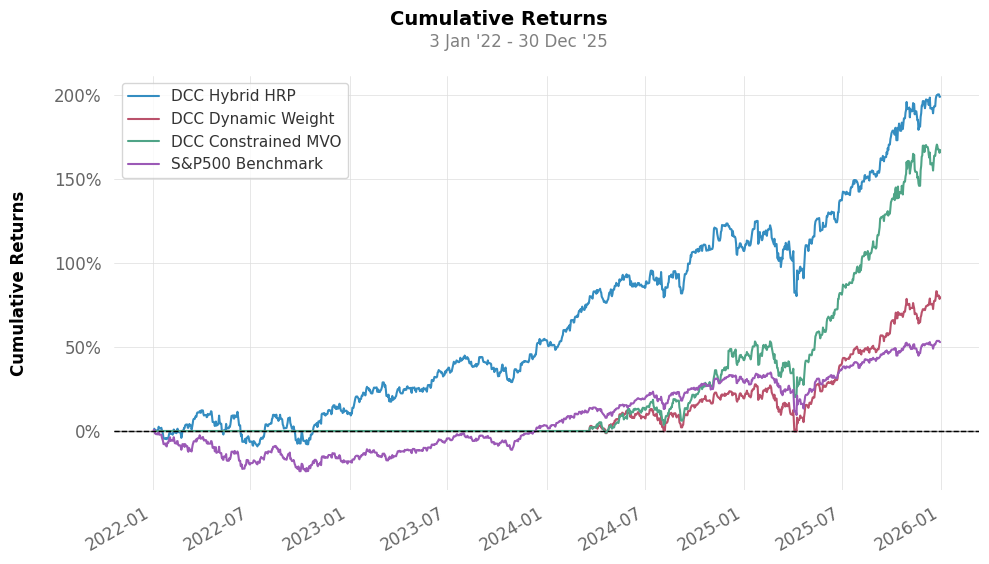

In [26]:
#Master Growth Plot
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
                'DCC Hybrid HRP': hybrid_daily_rets,
                'DCC Dynamic Weight': staggered_rets,
                'DCC Constrained MVO': mvo_daily_rets,
                'S&P500 Benchmark': qs.utils.download_returns('SPY')
})

comparison_df = comparison_df.loc[hybrid_daily_rets.index]       #Keeping S&P500 to same timeframe

plt.figure(figsize=(12,7))
qs.plots.returns(comparison_df)

In [27]:
results = {
          'DCC Hybrid HRP': hybrid_daily_rets,
          'DCC Dynamic Weight': staggered_rets,
          'DCC Constrained MVO': mvo_daily_rets,
          'S&P500 Benchmark': qs.utils.download_returns('SPY')
}

results_df = pd.DataFrame(results).loc[hybrid_daily_rets.index].dropna()

summary = []                              #Most important summary statistics
for name in results_df.columns:
  rets = results_df[name]
  summary.append({
        "Model": name,
        "Sharpe": qs.stats.sharpe(rets),
        "Sortino": qs.stats.sortino(rets),
        "Max Drawdown %": qs.stats.max_drawdown(rets) * 100,
        "Annual Return %": qs.stats.cagr(rets) * 100,
        "Volatility %": qs.stats.volatility(rets) * 100,
        "Tail Ratio": qs.stats.tail_ratio(rets)        #1.0 means biggest losses are equal to biggest wins, 0.94 means portfolio crashes harder than it rallies on best days
    })

comparison_table = pd.DataFrame(summary).set_index("Model")
print(comparison_table.round(2))

                     Sharpe  Sortino  Max Drawdown %  Annual Return %  \
Model                                                                   
DCC Hybrid HRP         1.56     2.28          -19.90            34.66   
DCC Dynamic Weight     1.54     2.24          -22.18            36.05   
DCC Constrained MVO    2.32     3.57          -21.63            71.94   
S&P500 Benchmark       1.11     1.65          -18.76            18.97   

                     Volatility %  Tail Ratio  
Model                                          
DCC Hybrid HRP              20.49        1.01  
DCC Dynamic Weight          21.55        1.04  
DCC Constrained MVO         24.67        1.09  
S&P500 Benchmark            16.89        0.89  


**DCC-GARCH Hybrid HRP Tearsheet**
---
---

In [28]:
benchmark=qs.utils.download_returns('SPY')

common_index = hybrid_daily_rets.index.intersection(benchmark.index)   #QS download_returns only includes trading days, hybrid_daily_rets includes weekends

hybrid_rets_clean = hybrid_daily_rets.loc[common_index].rename("DCC Hybrid HRP")
benchmark_clean = benchmark.loc[common_index].rename("S&P 500")

qs.reports.html(hybrid_rets_clean, benchmark=benchmark_clean, output='DCC_HRP_Hybrid_Tearsheet.html')